<a href="https://colab.research.google.com/github/Hawlll/Hancoded_MLAlgos/blob/main/GaussianNB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns

In [147]:
class GaussianNB:

  def __init__(self, threshold=0.5):

    self.threshold = threshold
    self.feat_dists = None
    self.class_priors = None
    self.classes = None

  def fit(self, X, y):

    self.classes = np.unique(y)

    self.class_priors = [np.sum(y == cls) / len(y) for cls in self.classes]

    self.feat_dists = []
    for i in range(len(self.classes)):
      feat_dists = []
      for j in range(X.shape[1]):
        feat_dists.append([np.mean(X[y == self.classes[i]][:, j]), np.std(X[y == self.classes[i]][:, j])])
      self.feat_dists.append(feat_dists)

  def predict(self, X):

    y_probs = []
    for record in X:
      class_probs = np.array([1 for _ in range(len(self.classes))], dtype=float)
      for i in range(len(self.classes)):
        for j in range(len(record)):

          feat_mean, feat_std = self.feat_dists[i][j][0], self.feat_dists[i][j][1] + 1e-15
          x_j = record[j]

          exponent = np.exp((-1/2)*((x_j - feat_mean) / feat_std)**2)

          prob = (1 / (feat_std * np.sqrt(2*np.pi))) * exponent
          class_probs[i] *= prob

      class_probs[i] *= self.class_priors[i]
      class_probs /= np.sum(class_probs)
      y_probs.append(class_probs)

    y_probs = np.array(y_probs)

    return y_probs, np.argmax(y_probs, axis=1)



In [148]:
data = load_iris(return_X_y=True)
X, y = data[0], data[1]
X[:10], y[:10]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [149]:
gnb = GaussianNB()
gnb.fit(X, y)
probs, class_preds = gnb.predict(X)
probs[:10], class_preds[:10]

(array([[1.00000000e+00, 1.35784018e-18, 2.37094161e-26],
        [1.00000000e+00, 1.51480506e-17, 7.82732413e-26],
        [1.00000000e+00, 1.07303991e-18, 7.80088167e-27],
        [1.00000000e+00, 1.46619287e-17, 9.84974373e-26],
        [1.00000000e+00, 4.53291077e-19, 9.61298511e-27],
        [1.00000000e+00, 1.49094089e-14, 5.85839711e-22],
        [1.00000000e+00, 1.10262518e-17, 9.03814435e-26],
        [1.00000000e+00, 6.53643441e-18, 9.24453044e-26],
        [1.00000000e+00, 9.42225434e-18, 4.01476653e-26],
        [1.00000000e+00, 3.42347739e-18, 4.02501653e-26]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

Accuracy: 96.0%


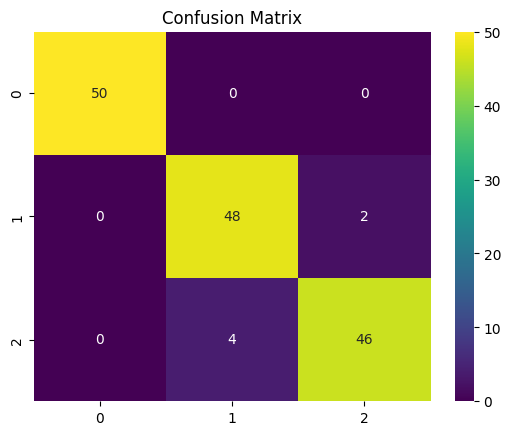

In [150]:
conf_matrix = np.zeros((len(gnb.classes), len(gnb.classes)))

for i in range(len(y)):

  y_true, y_pred = y[i], class_preds[i]
  conf_matrix[y_true][y_pred] += 1

sns.heatmap(conf_matrix, cmap='viridis', annot=True)
plt.title("Confusion Matrix")

acc = np.sum(np.diag(conf_matrix)) / np.sum(conf_matrix)
print("Accuracy: {}%".format(np.around(acc*100, 3)))

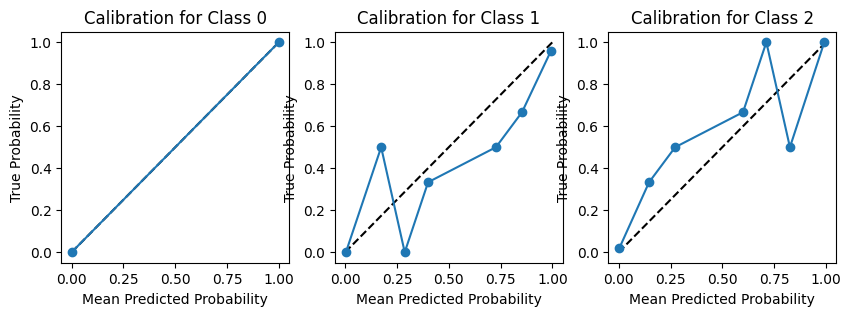

In [151]:
fig = plt.figure(figsize=(10, len(gnb.classes)))

for i in range(len(gnb.classes)):

  probs_bins = np.linspace(0, 1, 10)
  true_probs = []
  pred_probs = []
  for j in range(len(probs_bins)-1):
    mask = (probs[:, i] >= probs_bins[j]) & (probs[:, i] < probs_bins[j+1])

    if probs[mask].shape[0] > 0:
      true_probs.append(np.sum(y[mask] == gnb.classes[i]) / probs[mask].shape[0])
      pred_probs.append(np.sum(probs[mask, i]) / probs[mask].shape[0])

  plt.subplot(1, len(gnb.classes), i+1)
  plt.title("Calibration for Class {}".format(gnb.classes[i]))
  plt.xlabel("Mean Predicted Probability")
  plt.ylabel("True Probability")
  plt.plot([0, 1], [0, 1], 'k--')
  plt.plot(pred_probs, true_probs, 'o-')